In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("NovaMarket_datos_crudos.csv")

# MCAR

In [2]:
# Proporción de categoría de producto en las filas con precio faltante
df[df["precio_unitario"].isnull()]["categoria_producto"].value_counts(normalize=True)

# Proporción de categoría de producto en todo el dataset
df["categoria_producto"].value_counts(normalize=True)

categoria_producto
Moda            0.087769
Belleza         0.087550
Electrónica     0.087512
Juguetería      0.087502
Hogar           0.087142
Deportes        0.087025
hogar           0.031911
deportes        0.031461
belleza         0.031419
moda            0.031286
ELECTRÓNICA     0.016213
 Juguetería     0.016033
Hogar           0.016008
 Hogar          0.016002
 Belleza        0.016000
jugueteria      0.015983
Juguetería      0.015975
 Deportes       0.015963
 Moda           0.015927
Belleza         0.015898
electrónica     0.015895
Moda            0.015895
JUGUETERÍA      0.015892
HOGAR           0.015886
MODA            0.015841
BELLEZA         0.015773
electronica     0.015770
Deportes        0.015755
Electrónica     0.015731
DEPORTES        0.015691
 Electrónica    0.015684
juguetería      0.015609
Name: proportion, dtype: float64

# MAR

In [3]:
# Porcentaje de nivel_satisfaccion faltante, por canal de compra
df.groupby("canal_compra")["nivel_satisfaccion"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            20.8
 Marketplace     2.9
 Tienda          3.0
 Web             2.6
APP             20.4
App             20.4
App             19.7
MARKETPLACE      3.1
Marketplace      2.9
Marketplace      3.0
TIENDA           2.9
Tienda           3.0
Tienda           2.8
WEB              2.5
Web              2.8
Web              2.8
app             20.2
marketplace      2.9
tienda           3.0
web              3.1
Name: nivel_satisfaccion, dtype: float64

# MNAR

### No lo he hecho

# Eliminación

## Columnas

In [4]:
porcentaje_nulos = df.isna().mean()

# Filtra las columnas con 90% o más de faltantes
columnas_90 = porcentaje_nulos[porcentaje_nulos > 0.9]

print(columnas_90)

Series([], dtype: float64)


In [ ]:
# Elimina una columna con demasiados valores faltantes
df_sin_columna = df.drop(columns=["columna_con_90pct_faltante"])

## Filas

In [ ]:
# Elimina las filas donde precio_unitario es nulo
df_sin_nulos_precio = df.dropna(subset=["precio_unitario"])

# Imputación

## Media o mediana

In [ ]:
# Con la mediana (recomendada si la distribución está sesgada, ver Semana 2)
df["precio_unitario"] = df["precio_unitario"].fillna(df["precio_unitario"].median())

## Moda

In [ ]:
df["ciudad_tienda"] = df["ciudad_tienda"].fillna(df["ciudad_tienda"].mode()[0])

## Valor constante

In [ ]:
df["ciudad_tienda"] = df["ciudad_tienda"].fillna("Desconocida")

## Por grupo (MAR)

In [ ]:
# Imputa la moda de nivel_satisfaccion, calculada por separado dentro de cada canal
df["nivel_satisfaccion"] = df.groupby("canal_compra")["nivel_satisfaccion"].transform(
    lambda serie: serie.fillna(serie.mode()[0])
)

# Columna indicadora

In [ ]:
# Imputa la moda de nivel_satisfaccion, calculada por separado dentro de cada canal
df["nivel_satisfaccion"] = df.groupby("canal_compra")["nivel_satisfaccion"].transform(
    lambda serie: serie.fillna(serie.mode()[0])
)

# TAREA DE LA SEMANA

In [5]:
df.isnull().sum()

id_pedido                         0
id_cliente                        0
fecha_pedido                      0
canal_compra                      0
metodo_pago                       0
ciudad_tienda                 29925
codigo_postal                     0
categoria_producto                0
producto                          0
precio_unitario               21698
unidades_vendidas                 0
monto_compra                  21698
edad_cliente                      0
correo_cliente               105226
nivel_satisfaccion            46402
nivel_lealtad                     0
comentario_cliente            90882
peso_pedido_kg                    0
fecha_actualizacion_stock         0
fuga_cliente                      0
dtype: int64

Se analizarán: ciudad_tienda, precio_unitario, monto_compra, correo_cliente, nivel_satisfaccion, comentario_cliente

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

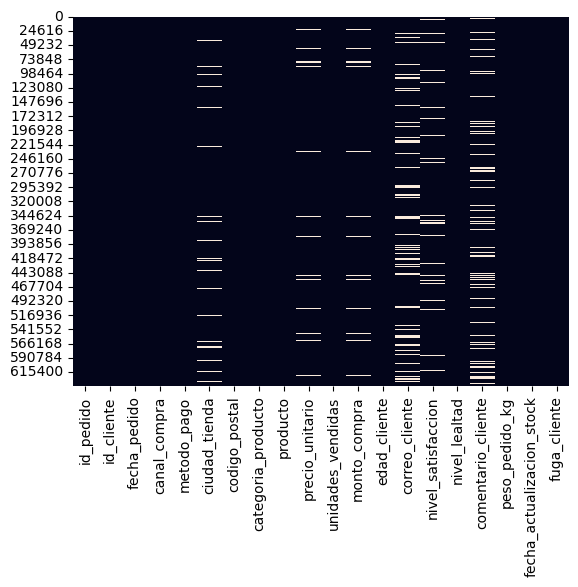

In [7]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [8]:
df[df["precio_unitario"].isnull()]["categoria_producto"].value_counts(normalize=True)

categoria_producto
Belleza         0.089686
Electrónica     0.089087
Moda            0.088764
Deportes        0.086920
Hogar           0.085768
Juguetería      0.081620
deportes        0.033367
moda            0.033045
hogar           0.031155
belleza         0.029358
electrónica     0.017329
juguetería      0.017098
jugueteria      0.016960
Belleza         0.016822
Hogar           0.016730
Juguetería      0.016730
 Electrónica    0.016684
 Deportes       0.016407
 Hogar          0.016361
DEPORTES        0.016315
BELLEZA         0.016084
 Juguetería     0.016038
MODA            0.015808
HOGAR           0.015808
Electrónica     0.015762
 Moda           0.015716
electronica     0.015301
JUGUETERÍA      0.015255
 Belleza        0.014886
ELECTRÓNICA     0.014794
Moda            0.014425
Deportes        0.013918
Name: proportion, dtype: float64

In [9]:
df["categoria_producto"].value_counts(normalize=True)

categoria_producto
Moda            0.087769
Belleza         0.087550
Electrónica     0.087512
Juguetería      0.087502
Hogar           0.087142
Deportes        0.087025
hogar           0.031911
deportes        0.031461
belleza         0.031419
moda            0.031286
ELECTRÓNICA     0.016213
 Juguetería     0.016033
Hogar           0.016008
 Hogar          0.016002
 Belleza        0.016000
jugueteria      0.015983
Juguetería      0.015975
 Deportes       0.015963
 Moda           0.015927
Belleza         0.015898
electrónica     0.015895
Moda            0.015895
JUGUETERÍA      0.015892
HOGAR           0.015886
MODA            0.015841
BELLEZA         0.015773
electronica     0.015770
Deportes        0.015755
Electrónica     0.015731
DEPORTES        0.015691
 Electrónica    0.015684
juguetería      0.015609
Name: proportion, dtype: float64

## Diagnóstico de precio_unitario

Se mantienen las proporciones, por lo tanto, se puede concluir que es MCAR

In [10]:
df.groupby("canal_compra")["nivel_satisfaccion"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            20.8
 Marketplace     2.9
 Tienda          3.0
 Web             2.6
APP             20.4
App             20.4
App             19.7
MARKETPLACE      3.1
Marketplace      2.9
Marketplace      3.0
TIENDA           2.9
Tienda           3.0
Tienda           2.8
WEB              2.5
Web              2.8
Web              2.8
app             20.2
marketplace      2.9
tienda           3.0
web              3.1
Name: nivel_satisfaccion, dtype: float64

## Diagnóstico de nivel_satisfaccion

Se puede evidenciar que los registros con más valores faltantes en la columna "nivel_satisfacción" son los que compraron mediante la App. esto nos hace sospechar que estamos lidiando con un MAR

In [15]:
df.groupby("categoria_producto")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        4.3
 Deportes       4.6
 Electrónica    5.1
 Hogar          4.9
 Juguetería     5.0
 Moda           4.7
BELLEZA         4.8
Belleza         4.6
Belleza         4.9
DEPORTES        4.8
Deportes        4.5
Deportes        4.6
ELECTRÓNICA     4.6
Electrónica     4.6
Electrónica     5.0
HOGAR           5.1
Hogar           4.7
Hogar           4.8
JUGUETERÍA      4.3
Juguetería      4.6
Juguetería      4.7
MODA            4.7
Moda            4.8
Moda            4.5
belleza         4.9
deportes        4.6
electronica     4.8
electrónica     4.7
hogar           4.9
jugueteria      4.4
juguetería      4.4
moda            4.7
Name: ciudad_tienda, dtype: float64

In [16]:
df.groupby("canal_compra")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            4.6
 Marketplace    4.7
 Tienda         4.8
 Web            4.6
APP             4.5
App             4.7
App             4.9
MARKETPLACE     4.9
Marketplace     4.6
Marketplace     4.9
TIENDA          4.8
Tienda          4.6
Tienda          4.6
WEB             4.3
Web             4.7
Web             5.0
app             4.9
marketplace     4.5
tienda          4.8
web             4.5
Name: ciudad_tienda, dtype: float64

In [17]:
df.groupby("categoria_producto")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        16.4
 Deportes       16.1
 Electrónica    16.6
 Hogar          16.2
 Juguetería     16.2
 Moda           16.3
BELLEZA         16.2
Belleza         16.6
Belleza         16.8
DEPORTES        16.4
Deportes        16.6
Deportes        16.2
ELECTRÓNICA     16.8
Electrónica     16.3
Electrónica     16.0
HOGAR           16.4
Hogar           16.2
Hogar           16.5
JUGUETERÍA      16.4
Juguetería      16.5
Juguetería      16.9
MODA            16.7
Moda            16.4
Moda            16.7
belleza         16.9
deportes        16.2
electronica     16.6
electrónica     16.5
hogar           16.4
jugueteria      16.2
juguetería      16.8
moda            16.6
Name: correo_cliente, dtype: float64

In [18]:
df.groupby("canal_compra")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            16.8
 Marketplace    16.9
 Tienda         17.6
 Web            16.4
APP             16.5
App             16.6
App             16.3
MARKETPLACE     15.7
Marketplace     16.3
Marketplace     16.4
TIENDA          16.7
Tienda          16.5
Tienda          15.7
WEB             16.8
Web             16.5
Web             16.3
app             15.8
marketplace     16.2
tienda          16.3
web             16.1
Name: correo_cliente, dtype: float64

## Diagnóstico de ciudad_tienda

Los faltantes tienen proporciones parecidas en cada uno de los grupos, por lo tanto es MCAR

## Diagnóstico de ciudad_tienda

Los faltantes tienen proporciones parecidas en cada uno de los grupos, por lo tanto es MCAR

## Tabla de decisiones

| Columna | Mecanismo | % faltante | Estrategia elegida | Justificación |
|---|---|---:|---|---|
| `ciudad_tienda` | MCAR | 4.68% | Eliminación de filas | Presenta menos del 5% de valores faltantes. Si los faltantes son MCAR, eliminar las filas afectadas tiene un impacto reducido sobre el conjunto de datos y evita inventar información. |
| `precio_unitario` | MCAR | 3.39% | Eliminación de filas | Presenta un porcentaje bajo de faltantes (3.39%). Al estar por debajo del 5% y asumir un mecanismo MCAR, se pueden eliminar las filas afectadas sin una pérdida significativa de información. |
| `monto_compra` | MAR | 3.39% | Imputación por grupo | El porcentaje de faltantes es bajo y el valor puede estar relacionado con variables observadas como `precio_unitario`, `unidades_vendidas` o `categoria_producto`. Se propone imputar utilizando información del grupo correspondiente para aprovechar los datos observados. |
| `correo_cliente` | MNAR / sospechado | 16.44% | Columna indicadora, sin imputar | La ausencia del correo podría estar relacionada con la decisión del cliente de no proporcionar este dato. Imputar un correo sería inventar información, por lo que se conservará el faltante mediante una columna indicadora. |
| `nivel_satisfaccion` | MAR | 7.25% | Imputación por grupo | El porcentaje de faltantes es moderado y la satisfacción puede estar relacionada con variables observadas, como el canal de compra o la categoría del producto. Se propone imputar utilizando el comportamiento del grupo correspondiente. |
| `comentario_cliente` | MNAR / sospechado | 14.20% | Columna indicadora, sin imputar | La ausencia de un comentario puede depender de la decisión del propio cliente de no escribir uno. Debido a que no sería apropiado inventar un comentario, se conservarán los faltantes y se añadirá una columna indicadora. |

In [19]:
df = df.dropna(subset=["precio_unitario"])
df = df.dropna(subset=["ciudad_tienda"])

In [20]:
df.shape

(589386, 20)

In [22]:
df["monto_compra"] = (
    df["monto_compra"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .replace("nan", pd.NA)
)

df["monto_compra"] = pd.to_numeric(
    df["monto_compra"],
    errors="coerce"
)

In [23]:
df["monto_compra"] = (
    df["monto_compra"]
    .fillna(
        df.groupby("categoria_producto")["monto_compra"]
        .transform("median")
    )
)

In [24]:
df["nivel_satisfaccion"] = (
    df["nivel_satisfaccion"]
    .astype("string")
    .str.strip()
    .str.lower()
)

In [25]:
moda_satisfaccion = (
    df.groupby("canal_compra")["nivel_satisfaccion"]
    .transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
    )
)

df["nivel_satisfaccion"] = (
    df["nivel_satisfaccion"]
    .fillna(moda_satisfaccion)
)

In [26]:
df["correo_cliente_faltante"] = (
    df["correo_cliente"].isna().astype(int)
)

In [27]:
df["comentario_cliente_faltante"] = (
    df["comentario_cliente"].isna().astype(int)
)

In [28]:
df.to_csv(
    "S04_PD_Lozano_DatasetImputacionInicial.csv",
    index=False
)